In [1]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import pandas            as pd
import SO_library        as sol
import json
import os

# Assuming the `bin` directory is in the user's home directory
# For sqs
home_directory = os.path.expanduser("~")
bin_directory = os.path.join(home_directory, "bin")
os.environ["PATH"] += os.pathsep + bin_directory

from pymatgen.core.surface   import generate_all_slabs
from pymatgen.core.structure import Structure
from pymatgen.io.ase         import AseAtomsAdaptor
from ase.io.vasp             import write_vasp

sns.set_theme()

We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name of folder and path to reference POSCAR
general_folder = 'input/SbSeI'
path_to_POSCAR = 'POSCAR-uc-SbSeI'

# Maximum number for the Miller index in each direction
max_index = 2

# Whether to repair terminations with broken bonds or just omit them
repair = True

# Minimum thicknesses for slab and vacuum
min_slab_size   = 20.0
min_vacuum_size = 20.0

relax_bulk = False

# Define paths to pretrained model and structure to be relaxed
# Materials Project pretrained model as default
#model_load_path = '../../UCL/m3gnet/finetuned_model'
model_load_path = None
model_load_path = 'large' if model_load_path is None else model_load_path
model_load_path

'large'

In [3]:
# Move POSCAR to defect folder
# The folder is named as defects_x_y_z_vi (eg, defects_0_1_0.5_v0)
# Each new run generates a new folder, with different defects most likely (as POSCAR will vary as well)
i = 0
while True:
    if not os.path.exists(general_folder):
        # Generate new folder
        os.system(f'mkdir {general_folder}')
    
    slab_folder = f'{general_folder}/slab_v{i}'
    if not os.path.exists(slab_folder):
        # Generate new folder
        os.system(f'mkdir {slab_folder}')

        # Copy POSCAR there (named as unticell, and POSCAR for creating supercell)
        os.system(f'cp {path_to_POSCAR} {slab_folder}/POSCAR')
        break
    i +=1
slab_folder

'input/SbSeI/slab_v0'

# ML-IAP relaxation

In [4]:
# Unit-cell relaxation

# Define paths to bulk and POSCAR
path_to_bulk = f'{slab_folder}/bulk'

# Generate directory for current slab
os.system(f'mkdir {path_to_bulk}')

# Copy POSCAR to new directory
os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/POSCAR')

if relax_bulk:
    # Relax the structure, hiding the output (verbose=False)
    _ = sol.structural_relaxation(f'{path_to_bulk}/POSCAR',
                                  model_load_path,
                                  output_folder=path_to_bulk)

    # Get the single-shot energy
    bulk_energy, _, _ = sol.single_shot_energy_calculation(f'{path_to_bulk}/CONTCAR',
                                                           model_load_path)
else:
    os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/CONTCAR')

# Read relaxed structure
structure = Structure.from_file(f'{path_to_bulk}/CONTCAR')

# Save slab information
slab_data = {
    'number_of_sites': structure.num_sites,
}
with open(f'{path_to_bulk}/slab_data.json', 'w') as json_file:
    json.dump(slab_data, json_file)

# Slab generation

In [5]:
# Generate all slabs
slabs = generate_all_slabs(structure,
                           max_index=max_index,
                           min_slab_size=min_slab_size,
                           min_vacuum_size=min_vacuum_size,
                           repair=repair)

# Get energy per atom
#bulk_energy_per_atom = bulk_energy / structure.num_sites

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['wyckoffs']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['equivalent_atoms']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(


In [6]:
for n, slab in enumerate(slabs):
    print(n, "Polar:", slab.is_polar(), "Symmetric: ", slab.is_symmetric())

0 Polar: False Symmetric:  False
1 Polar: False Symmetric:  False
2 Polar: False Symmetric:  False
3 Polar: False Symmetric:  False
4 Polar: False Symmetric:  False
5 Polar: False Symmetric:  True
6 Polar: False Symmetric:  True
7 Polar: False Symmetric:  False
8 Polar: False Symmetric:  False
9 Polar: False Symmetric:  True
10 Polar: False Symmetric:  True
11 Polar: False Symmetric:  False
12 Polar: False Symmetric:  False
13 Polar: False Symmetric:  True
14 Polar: False Symmetric:  True
15 Polar: False Symmetric:  False
16 Polar: False Symmetric:  False
17 Polar: False Symmetric:  False
18 Polar: False Symmetric:  False
19 Polar: False Symmetric:  False
20 Polar: False Symmetric:  True
21 Polar: False Symmetric:  False
22 Polar: False Symmetric:  False
23 Polar: False Symmetric:  True
24 Polar: False Symmetric:  True
25 Polar: False Symmetric:  True
26 Polar: False Symmetric:  False
27 Polar: False Symmetric:  False
28 Polar: False Symmetric:  True
29 Polar: False Symmetric:  True
30

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [7]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
slab_energies = {}
for i, slab in enumerate(slabs):
    print()
    print(f'Slab {i+1}')
    print()
    print('Miller index:', slab.miller_index)
    print('Shift:', slab.shift)
    print('Surface area:', slab.surface_area)
    print('Number of sites:', len(slab.sites))

    # Miller index tuple to string
    miller_index_str = '_'.join(str(element) for element in slab.miller_index)
    miller_index_str = f'{miller_index_str}_i_{i}'

    # Define current folder
    current_folder = f'{slab_folder}/{miller_index_str}'

    # Generate new folder
    os.system(f'mkdir {current_folder}')

    # Save slab into current_folder
    write_vasp(f'{current_folder}/POSCAR', AseAtomsAdaptor.get_atoms(slab), direct=True, sort=True)

    # Save slab information
    slab_data = {
        'miller_index': slab.miller_index,
        'shift': slab.shift,
        'surface_area': slab.surface_area,
        'number_of_sites': len(slab.sites),
        'is_polar': str(slab.is_polar()),
        'is_symmetric': str(slab.is_symmetric())
    }
    with open(f'{current_folder}/slab_data.json', 'w') as json_file:
        json.dump(slab_data, json_file)
    '''
    # Relax the structure, hiding the output (verbose=False)
    _ = sol.structural_relaxation(f'{current_folder}/POSCAR',
                                  model_load_path,
                                  relax_cell=False,
                                  output_folder=current_folder)

    # Get and save the single-shot energy
    ssc_energy, _, _ = sol.single_shot_energy_calculation(f'{current_folder}/CONTCAR',
                                                          model_load_path)
    np.savetxt(f'{current_folder}/single_shot_energy', [ssc_energy])

    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / len(slab.sites)

    # Compute slab energy in eV/atom/ang^2
    slab_energy = (ssc_energy_per_atom - bulk_energy_per_atom) / (2 * slab.surface_area)

    print(f'\t{slab_energy} eV/atom/Å^2')

    # Generate a dictionary object with the new data and update in the main data object
    slab_energies.update({
        (miller_index_str): slab_energy
    })
    '''

# Convert to Pandas DataFrame
#slab_energies = pd.DataFrame(slab_energies, index=['energy'])


Slab 1

Miller index: (1, 1, 1)
Shift: 0.0435166994048366
Surface area: 103.08911269228192
Number of sites: 72

Slab 2

Miller index: (1, 1, 1)
Shift: 0.17285706814294954
Surface area: 103.08911269228192
Number of sites: 72

Slab 3

Miller index: (1, 1, 1)
Shift: 0.3114037822653444
Surface area: 103.08911269228192
Number of sites: 72

Slab 4

Miller index: (1, 1, 1)
Shift: 0.40275950419699313
Surface area: 103.08911269228192
Number of sites: 72

Slab 5

Miller index: (1, 1, 1)
Shift: 0.4527810068172613
Surface area: 103.08911269228192
Number of sites: 72

Slab 6

Miller index: (1, 1, 1)
Shift: 0.5000000000000036
Surface area: 103.08911269228192
Number of sites: 72

Slab 7

Miller index: (1, 1, 0)
Shift: 7.105427357601002e-15
Surface area: 97.01243224066874
Number of sites: 72

Slab 8

Miller index: (1, 1, 0)
Shift: 0.10253254098215697
Surface area: 97.01243224066874
Number of sites: 72

Slab 9

Miller index: (1, 1, 0)
Shift: 0.1800320500569868
Surface area: 97.01243224066874
Number of

# Extract local minimas and generate input files

In [8]:
# Sorted in ascendent order
min_arg       = np.argsort(slab_energies.values)[0]
local_minimas = slab_energies.columns[min_arg]
energies      = slab_energies.values[0][min_arg]

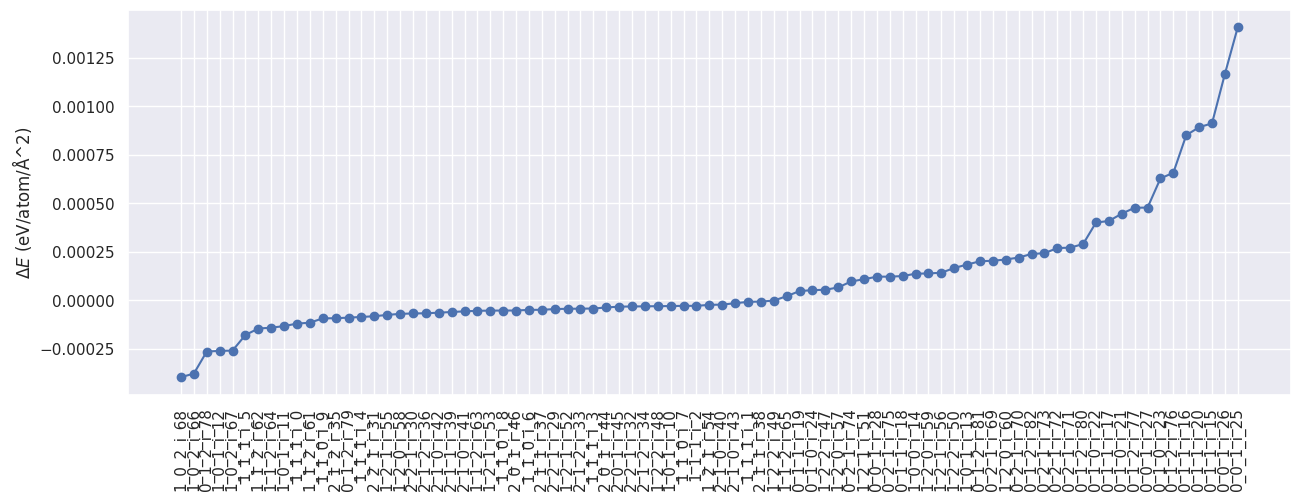

In [9]:
# Energy differences in eV/supercell
plt.figure(figsize=(15, 5))
plt.plot(energies, 'o-')
plt.xticks(range(len(local_minimas)), local_minimas, rotation='vertical')
plt.ylabel(r'$\Delta E$ (eV/atom/Å^2)')
plt.savefig(f'{slab_folder}/ranking.eps', dpi=50, bbox_inches='tight')
plt.show()